In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jax import config
config.update("jax_enable_x64", False)
import jax.numpy as jnp

import jax

config.update("jax_enable_x64", True)
import os, sys
sys.path.insert(0, r"C:\Users\Owner\time_domain_work\simphony")
from simphony.circuit import Circuit
from simphony.simulation import SampleModeSimulation
from simphony.libraries import siepic

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
from functools import partial
from simphony.time_domain.utils import gaussian_pulse
from simphony.circuit.components import SampleModeComponent
from jaxtyping import ArrayLike
from simphony.simulation.sample_mode import SampleModeSimulationParameters
from simphony.signals import SampleModeOpticalSignal
from commpy.filters import rrcosfilter
from scipy.signal import upfirdn
from jax import lax
import sax

In [2]:
class StreamingCombSourceTime(SampleModeComponent):
    optical_ports = ["o0"]

    def __init__(self, base_wavelengths, linewidth=0.0, amps=None, freqs=None, phases=None):
        bw = jnp.asarray(base_wavelengths, jnp.float32)
        self.base   = bw
        self.linewd = jnp.float32(linewidth)
        self.amps   = jnp.asarray(amps,   jnp.float32) if amps   is not None else jnp.zeros_like(bw)
        self.freqs  = jnp.asarray(freqs,  jnp.float32) if freqs  is not None else jnp.zeros_like(bw)
        self.phases = jnp.asarray(phases, jnp.float32) if phases is not None else jnp.zeros_like(bw)

    def sample_mode_initial_state(self, simulation_parameters):
        Ts = jnp.asarray(simulation_parameters.sampling_period, jnp.float32)
        M  = self.base.shape[0]
        w  = jnp.asarray(2*jnp.pi*self.freqs, jnp.float32)
        rot = jnp.exp(1j * w * Ts).astype(jnp.complex64)   # [M]
        z   = jnp.exp(1j * self.phases).astype(jnp.complex64)  # [M]
        phi = jnp.zeros((M,), jnp.float32)
        t_idx = jnp.int32(0)

        # pre-generate phase noise for THIS chunk only
        N = jnp.asarray(simulation_parameters.num_time_steps, jnp.int32)
        key = simulation_parameters.prng_key
        delta_phi_std = jnp.sqrt(jnp.float32(2*jnp.pi) * self.linewd * Ts)
        dphi = jax.random.normal(key, (N, M), dtype=jnp.float32) * delta_phi_std  # [N, M]

        return (phi, t_idx, rot, z, dphi)

    @partial(jax.jit, static_argnums=(0,))
    def sample_mode_step(self, inputs, state, simulation_parameters):
        phi, t_idx, rot, z, dphi = state
        # consume pre-generated noise
        phi = phi + dphi[t_idx]
        z   = z * rot
        drift = self.amps.astype(jnp.float32) * jnp.imag(z).astype(jnp.float32)  # [M]
        wls = (self.base + drift).astype(jnp.float32)
        A = jnp.exp(1j * phi.astype(jnp.float32)).astype(jnp.complex64)[:, None]  # [M,1]
        out = {"o0": SampleModeOpticalSignal(amplitude=A, wavelength=wls)}
        return out, (phi, t_idx + 1, rot, z, dphi)

In [ ]:
import numpy as np
import sax
from simphony.libraries import siepic
from scipy.signal import find_peaks

netlist = {
    "instances":{
        "hr1":"half_ring",
        "hr2":"half_ring",
        "wg1":"waveguide",
        "wg2":"waveguide",
    },
    "connections":{
        "hr1,port_1":"wg1,o0",
        "hr2,port_1":"wg1,o1",
        "hr1,port_3":"wg2,o0",
        "hr2,port_3":"wg2,o1",
    },
    "ports":{
        "o0":"hr1,port_2",
        "o1":"hr2,port_2",
        "o2":"hr1,port_4",
        "o3":"hr2,port_4",
    }
}
models = {
    "waveguide": siepic.waveguide,
    "half_ring": siepic.half_ring,
}

wvl = np.linspace(1.52, 1.58, 4001)
L_ref = 20.0
length_grid = np.linspace(0.0, 20.0, 901)
peak_height = 0.02
peak_distance_pts = 8
align_tol = 2e-5
avoid_tol = 5e-4
min_delta_L = 0.05
max_targets = 4

circuit, _ = sax.circuit(netlist=netlist, models=models)

def spectrum(L):
    s = circuit(**{"wl": wvl, "wg1": {"length": L}, "wg2": {"length": L}})
    T = np.abs(s[("o0","o2")])**2
    return T


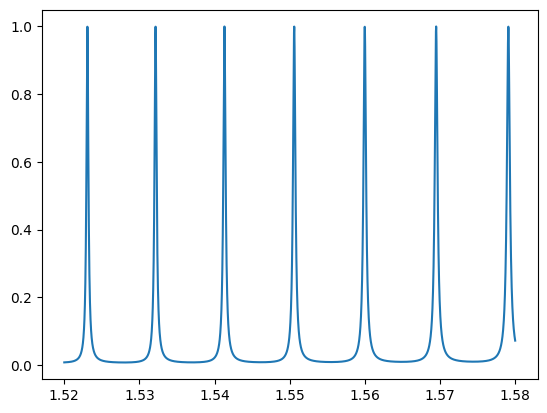

[0.26522691 0.29051185 0.26190985 0.28164102 0.2598861  0.29653364
 0.25736413 0.2753554  0.29421395 0.257719   0.26834343 0.29872152
 0.2636894  0.27395847 0.29351179 0.26133728 0.27299451 0.29993882
 0.26886005]
[1.52282  1.52333  1.531865 1.53242  1.541015 1.5416   1.54163  1.550285
 1.5509   1.55093  1.559645 1.560305 1.560335 1.569125 1.56983  1.56986
 1.57871  1.57946  1.57949 ]
[1.523075 1.53215  1.541315 1.5506   1.55999  1.569485 1.5791  ]


In [8]:
def find_resonances(L):
    T = spectrum(L)
    y = 1.0 - T
    plt.plot(wvl, y)
    plt.show()
    idx, props = find_peaks(y, height=peak_height, distance=peak_distance_pts)
    mask = (y > 0.25) & (y < 0.3)
    y_vals = y[mask]
    wvl_vals = wvl[mask]
    print(y_vals[::2])
    print(wvl_vals[::2])
    return wvl[idx]

res_ref = find_resonances(20)
print(res_ref)

In [ ]:
netlist = {
    "instances":{
        "hr1":"half_ring",
        "hr2":"half_ring",
        "wg1":"waveguide",
        "wg2":"waveguide",
    },
    "connections":{
        # "hr1,port_1":"hr2,port_1",
        # "hr1,port_3":"hr2,port_3",
        "hr1,port_1":"wg1,o0",
        "hr2,port_1":"wg1,o1",

        "hr1,port_3":"wg2,o0",
        "hr2,port_3":"wg2,o1",

    },
    "ports":{
        "o0":"hr1,port_2",
        "o1":"hr2,port_2",
        "o2":"hr1,port_4",
        "o3":"hr2,port_4",
    }
}
models = {
    "waveguide":siepic.waveguide,
    "y_branch": siepic.y_branch,
    "half_ring": siepic.half_ring,
}
wvl = np.linspace(1.5,1.6,4000)
settings = {
    "wl":wvl,
    "wg1":{"length":1.19},
    "wg2":{"length":1.19},

}
circuit, info = sax.circuit(
                        netlist=netlist,
                        models=models,
                    )
s = circuit(**settings)


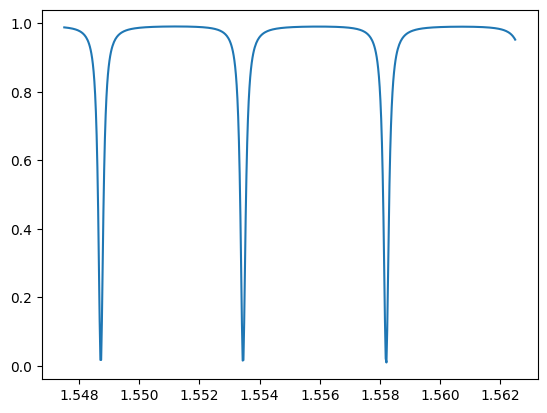

In [ ]:
settings = {
    "wl":wvl,
    "wg1":{"length":50},
    "wg2":{"length":50},

}
circuit, info = sax.circuit(
                        netlist=netlist,
                        models=models,
                    )
s = circuit(**settings)
plt.plot(wvl[1900:2500],np.abs(s[('o0','o2')][1900:2500])**2)
plt.show()

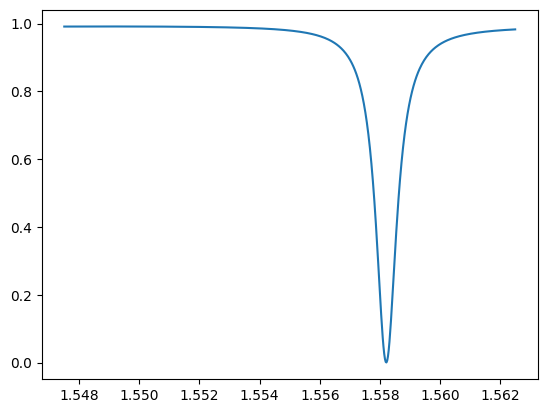

In [ ]:
settings = {
    "wl":wvl,
    "wg1":{"length":4.27},
    "wg2":{"length":4.27},

}
circuit, info = sax.circuit(
                        netlist=netlist,
                        models=models,
                    )
s = circuit(**settings)
plt.plot(wvl[1900:2500],np.abs(s[('o0','o2')][1900:2500])**2)
plt.show()

In [52]:
netlist = {
    "instances":{
        "laser":"laser",
        "hr1":"half_ring",
        "hr2":"half_ring",
        "wg1":"waveguide",
        "wg2":"waveguide",
    },
    "connections":{
        # "hr1,port_1":"hr2,port_1",
        # "hr1,port_3":"hr2,port_3",
        "laser,o0":"hr1,port_2",
        "hr1,port_1":"wg1,o0",
        "hr2,port_1":"wg1,o1",

        "hr1,port_3":"wg2,o0",
        "hr2,port_3":"wg2,o1",

    },
    "ports":{
        "o0":"hr1,port_2",
        "o1":"hr2,port_2",
        "o2":"hr1,port_4",
        "o3":"hr2,port_4",
    }
}
class StreamingCombSourceTime(SampleModeComponent):
    optical_ports = ["o0"]

    def __init__(self, base_wavelengths, linewidth=0.0, amps=None, freqs=None, phases=None):
        bw = jnp.asarray(base_wavelengths, jnp.float32)
        self.base   = bw
        self.linewd = jnp.float32(linewidth)
        self.amps   = jnp.asarray(amps,   jnp.float32) if amps   is not None else jnp.zeros_like(bw)
        self.freqs  = jnp.asarray(freqs,  jnp.float32) if freqs  is not None else jnp.zeros_like(bw)
        self.phases = jnp.asarray(phases, jnp.float32) if phases is not None else jnp.zeros_like(bw)

    def sample_mode_initial_state(self, simulation_parameters):
        Ts = jnp.asarray(simulation_parameters.sampling_period, jnp.float32)
        M  = self.base.shape[0]
        w  = jnp.asarray(2*jnp.pi*self.freqs, jnp.float32)
        rot = jnp.exp(1j * w * Ts).astype(jnp.complex64)
        z   = jnp.exp(1j * self.phases).astype(jnp.complex64)
        phi = jnp.zeros((M,), jnp.float32)
        t_idx = jnp.int32(0)
        N = jnp.asarray(simulation_parameters.num_time_steps, jnp.int32)
        key = simulation_parameters.prng_key
        delta_phi_std = jnp.sqrt(jnp.float32(2*jnp.pi) * self.linewd * Ts)
        dphi = jax.random.normal(key, (N, M), dtype=jnp.float32) * delta_phi_std
        return (phi, t_idx, rot, z, dphi)

    @partial(jax.jit, static_argnums=(0,))
    def sample_mode_step(self, inputs, state, simulation_parameters):
        phi, t_idx, rot, z, dphi = state
        phi = phi + dphi[t_idx]
        z   = z * rot
        drift = self.amps.astype(jnp.float32) * jnp.imag(z).astype(jnp.float32)
        wls_local = (self.base + drift).astype(jnp.float32)
        A_local = jnp.exp(1j * phi.astype(jnp.float32)).astype(jnp.complex64)[:, None]

        wls_global = jnp.asarray(simulation_parameters.optical_baseband_wavelengths, jnp.float32)
        L = wls_global.shape[0]
        idx = jnp.argmin(jnp.abs(wls_global[:, None] - wls_local[None, :]), axis=0).astype(jnp.int32)
        A_full = jnp.zeros((L, 1), jnp.complex64)
        A_full = A_full.at[idx, 0].add(A_local[:, 0])

        out = {"o0": SampleModeOpticalSignal(amplitude=A_full, wavelength=wls_global)}
        return out, (phi, t_idx + 1, rot, z, dphi)

models = {
    "laser": StreamingCombSourceTime,
    "waveguide":siepic.waveguide,
    "y_branch": siepic.y_branch,
    "half_ring": siepic.half_ring,
}
wvl = np.linspace(1.5,1.6,500)
settings = {
    "laser":{"base_wavelengths":jnp.array([1.523075e-6, 1.532150e-6, 1.541315e-6, 1.550600e-6])},
    "wg1":{"length":20},
    "wg2":{"length":20},

}
circuit = Circuit(netlist=netlist, models=models)
sim = SampleModeSimulation(circuit = circuit)
simulation_parameters = SampleModeSimulationParameters(optical_baseband_wavelengths=jnp.array([1.523075e-6, 1.532150e-6, 1.541315e-6, 1.550600e-6]),
                                                       num_time_steps=int(1000000),sampling_period=1e-14)
results = sim.run(simulation_parameters=simulation_parameters, settings=settings)

Initial state for laser computed
Initial state for hr1 computed
Initial state for hr2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for _optical_termination0 computed
Initial state for _optical_termination1 computed
Initial state for _optical_termination2 computed
Starting simulation...
Completed 1 / 10 chunks 
Completed 2 / 10 chunks g: 399.277286529541
Completed 3 / 10 chunks g: 345.5051772594452
Completed 4 / 10 chunks g: 303.7103271484375
Completed 5 / 10 chunks g: 267.85061144828796
Completed 6 / 10 chunks g: 230.45325422286987
Completed 7 / 10 chunks g: 192.63339400291443
Completed 8 / 10 chunks g: 152.51521492004395
Completed 9 / 10 chunks g: 114.7875108718872
Completed 10 / 10 chunks : 76.04056930541992
Simulation time: 384.357 s 38.23958349227905


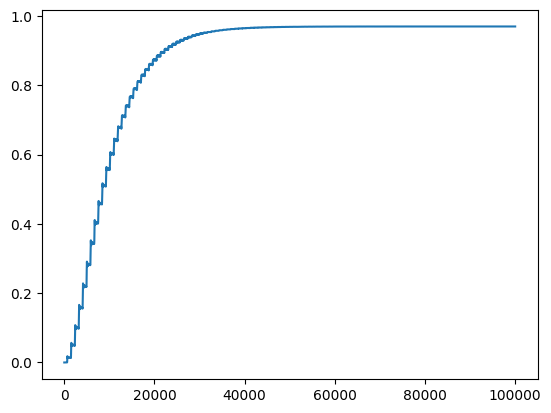

In [ ]:
plt.plot(np.abs(results["o1"]["output"].amplitude[0:20000,3,0]**2))
plt.show()

In [ ]:
results["o2"]["output"].amplitude.shape

(10000, 500, 1)